# Demo: `JointMotionScheme` and `CartesianMotionScheme`

This notebook demonstrates how to plan a motion for a simple `Planar3R` manipulator.

We start from a sequence of desired end-effector frames in Cartesian space. `JointMotionScheme` maps these target frames to joint coordinates and creates a time-scaled motion profile for each joint. Then we convert the result to a `CartesianMotionScheme` to inspect the resulting end-effector trajectory.

## Imports

The `sys.path` setup makes the notebook usable directly from the project root, even if the package has not been installed in editable mode.

In [1]:
from pathlib import Path
import sys

import numpy as np

PROJECT_ROOT = Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if SRC_PATH.exists() and str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from python_robot.base import Frame
from python_robot.models import Planar3R
from python_robot.motion import JointMotionScheme, MultiMotionProfileType

np.set_printoptions(precision=4, suppress=True)

## Robot and Target Frames

We use a planar three-revolute-joint robot with two non-zero link lengths. The target frames lie in the XY plane. The Z orientation angle is kept at zero so the example can focus on motion planning.

`dt_segments` defines the travel time for each segment between two successive target frames. Because a path with `n` target frames has `n - 1` segments, the number of values in `dt_segments` must be equal to `len(target_frames) - 1`.

In [2]:
robot = Planar3R(l1=1.0, l2=1.0)

target_frames = [
    Frame([0.65, 0.10, 0.0], [0.0, 0.0, 0.0]),
    Frame([0.45, 0.45, 0.0], [0.0, 0.0, 0.0]),
    Frame([0.85, 0.45, 0.0], [0.0, 0.0, 0.0]),
    Frame([0.65, 0.10, 0.0], [0.0, 0.0, 0.0]),
]

dt_segments = (2.0, 2.0, 2.0)

for i, frame in enumerate(target_frames):
    print(f"T{i}: origin={np.asarray(frame.origin)}, orient_angles={np.asarray(frame.orient_angles)}")

T0: origin=[0.65 0.1  0.  ], orient_angles=[0. 0. 0.]
T1: origin=[0.45 0.45 0.  ], orient_angles=[0. 0. 0.]
T2: origin=[0.85 0.45 0.  ], orient_angles=[0. 0. 0.]
T3: origin=[0.65 0.1  0.  ], orient_angles=[0. 0. 0.]


## Joint-Space Motion Scheme

`JointMotionScheme` first solves inverse kinematics for each target frame. It then creates one multipoint motion profile per joint. In this example, we use a cubic profile with zero start velocity and zero end velocity.

In [3]:
joint_scheme = JointMotionScheme(
    target_frames=target_frames,
    manipulator=robot,
    dt_segments=dt_segments,
    mp_type=MultiMotionProfileType.CUBIC,
    num_t_samples=100,
)

print("Joint coordinates at the target frames:")
print(joint_scheme.tables.coordinates)

print("\nFirst five rows of the joint-space timetable:")
scheme_lines = joint_scheme.tables.scheme.splitlines()
for line in scheme_lines[:7]:
    print(line)

Joint coordinates at the target frames:
+-------+----------+---------+----------+
| frame |       q1 |      q2 |       q3 |
+-------+----------+---------+----------+
|     0 | -62.0565 | 141.605 | -79.5487 |
|     1 |  -26.446 | 142.892 | -116.446 |
|     2 | -33.3595 | 122.514 | -89.1541 |
|     3 | -62.0564 | 141.605 | -79.5488 |
+-------+----------+---------+----------+

First five rows of the joint-space timetable:
+-----------+----------+---------+----------+
|      time |       q1 |      q2 |       q3 |
+-----------+----------+---------+----------+
|         0 | -62.0565 | 141.605 | -79.5487 |
| 0.0606061 | -61.9872 | 141.622 | -79.6349 |
|  0.121212 | -61.7838 | 141.671 | -79.8869 |
|  0.181818 | -61.4531 | 141.748 | -80.2949 |


## Plot the Joint Paths

The curves show the sampled joint positions over time. The markers show the joint values that correspond exactly to the target frames.

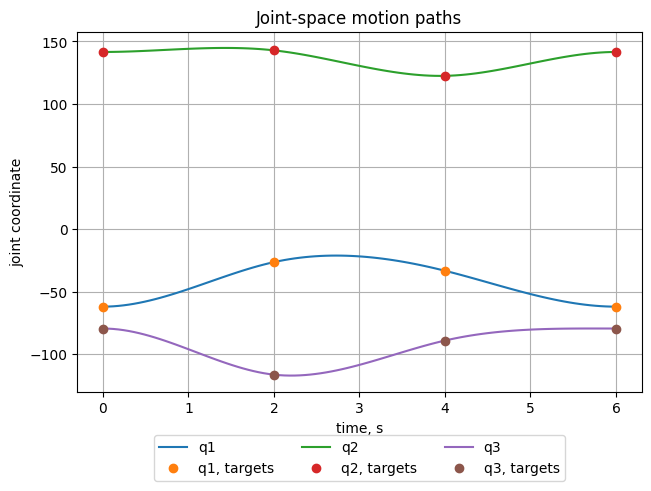

In [4]:
chart = joint_scheme.plot_motion_paths()
chart.add_title("Joint-space motion paths")
chart.show()

## Convert to Cartesian Space

`to_cartesian_space()` applies forward kinematics to every sampled joint configuration. This gives the actual end-effector trajectory generated by the joint-space motion scheme.

In [5]:
cartesian_scheme = joint_scheme.to_cartesian_space()

print("Joint-space scheme shape:", joint_scheme.scheme.shape)
print("Cartesian-space scheme shape:", cartesian_scheme.scheme.shape)

print("\nFirst and last Cartesian samples:")
print(np.round(cartesian_scheme.scheme[[0, -1]], 4))

Joint-space scheme shape: (100, 4)
Cartesian-space scheme shape: (100, 7)

First and last Cartesian samples:
[[ 0.    0.65  0.1   0.    0.   -0.    0.  ]
 [ 6.    0.65  0.1   0.    0.   -0.   -0.  ]]


## Plot the Cartesian Trajectory

This cell uses the asynchronous plotting method, which is useful in Jupyter. The blue points and lines show the original target frames. The orange line shows the trajectory produced by joint-space interpolation.

In [6]:
await cartesian_scheme.plot_trajectory_async(
    show_points=False,
    show_path=True,
    show_frames=False,
    show_target_path=True,
    show_target_points=False,
    show_target_frames=False,
    path_color="orange",
    target_path_color="blue",
    target_point_color="blue",
    target_frame_scale=0.12,
    extent=1.0,
    spacing=0.25
)

Widget(value='<iframe src="http://localhost:61135/index.html?ui=P_0x1d3f9464350_0&reconnect=auto" class="pyvis…

## Variant: Linear Profile with Parabolic Blends

For a linear multipoint profile, `blend_accels` must be provided. The example below uses the same target frames and segment durations, but changes the profiling of the motion.

`blend_accels` defines the acceleration used around the path points to round off the transitions between linear segments. Instead of stopping abruptly or changing velocity discontinuously at a target point, the profile inserts a parabolic blend. A single value applies the same blend acceleration to all joints and path points; a sequence can be used when different blend accelerations are needed.

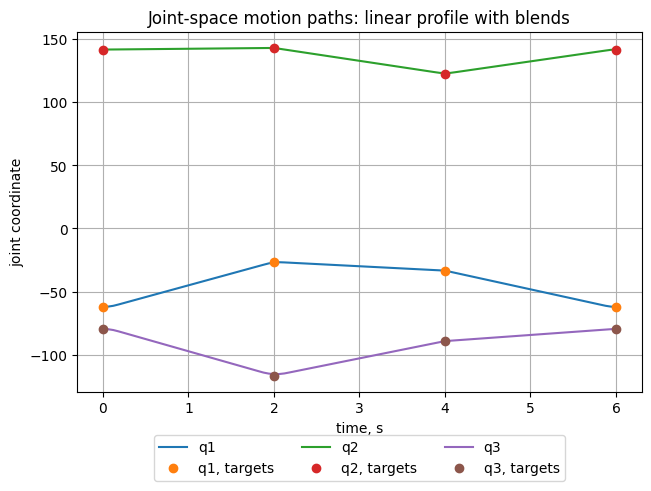

In [7]:
linear_joint_scheme = JointMotionScheme(
    target_frames=target_frames,
    manipulator=robot,
    dt_segments=dt_segments,
    mp_type=MultiMotionProfileType.LINEAR,
    blend_accels=2.0,
    num_t_samples=100,
)

chart = linear_joint_scheme.plot_motion_paths()
chart.add_title("Joint-space motion paths: linear profile with blends")
chart.show()

## Key Takeaways

- `JointMotionScheme.coordinates` contains only the joint values at the target frames.
- `JointMotionScheme.scheme` contains the full sampled timetable: time plus joint coordinates.
- `JointMotionScheme.plot_motion_paths()` visualizes the joint profiles.
- `JointMotionScheme.to_cartesian_space()` creates a `CartesianMotionScheme`.
- `CartesianMotionScheme.scheme` contains time, position `(x, y, z)`, and orientation `(alpha, beta, gamma)` of the end effector.
- The Cartesian path between target frames is not necessarily a straight line, because interpolation is performed in joint space.